In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 1/3 of population size
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [6894,
                              6895,
                              3080,
                              9031,
                              6980 # Vulbis
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        14093, # Botas kuko
                        18718, # Escudo kuko
                        14092, # Anillo kuko
                        8993, # Espada maldita
                        7754, # Dofus ocre
                    ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        29: {
                            "target": 80,  # Crit
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {}
                },

                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    8:1
                    },  # Exo MP
                "distributed_points": {
                    9: 995,  # Vitality
                },
                "elements" : [
                    36, # Agility,
                    22, # Chance
                    13, # Intelligence
                    45  # Strength
                ],
            },
        }

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')

In [4]:
Items[Items["name"].str.contains("kuko",case=False)]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [5]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2748
Total item sets: 148
Total pools:
   16 with sizes [69, 1, 1, 71, 62, 1, 1, 88, 69, 412, 1, 326, 326, 326, 326, 326]
Total combinations: 10^24.45


In [6]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniconda3/envs/optimization/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solut

In [9]:
for idx, solution in enumerate(sorted(solutions, key=lambda x: x.fitness, reverse=True)):
    if solution.penalized:
        continue
    print(f"Solution {idx}:")
    print("\tFitness:", solution.get_fitness())
    print("\tWeapon damage:", solution.get_final_damage(type="weapon"))
    print("\tSpell damage:", solution.get_final_damage(type="elements"))
    # print("\tIs the solution viable?", solution.viable)
    # print("\tWas the solution penalized?", solution.penalized)

    print("\tPreferences:")
    df = solution.totals_summary(effect_descriptions)
    for bound, preference in solution.preferences.items():
        for element, details in preference.items():
            row = df.loc[element]
            print(f"\t\t{row['description']} : {row['value']}")
    print("\tCharacteristics:")
    for element in elements:
        print(f"\t\t{df.loc[element]['description']}: {df.loc[element]['value']}")

    print("\tItems:")
    print("\t\tType\tDescription\tLevel")
    for item,row in solution.set_summary().sort_values("type").iterrows():
        # Prettify the output
        print(f"\t\t{row['type']}\t{row['description']}\t{row['level']}")

Solution 0:
	Fitness: 1914.3999999999999
	Weapon damage: 1914.3999999999999
	Spell damage: 1423.3200000000002
	Preferences:
		PA : 12.0
		PM : 6.0
		% crítico : 87.0
		vitalidad : 4910.0
		% resistencia neutral : 23.0
		% resistencia al fuego : 21.0
		% resistencia al aire : 36.0
		% resistencia al agua : 27.0
		% resistencia a la tierra : 37.0
	Characteristics:
		agilidad: 540.0
		suerte: 200.0
		inteligencia: 380.0
		fuerza: 540.0
		vitalidad: 4910.0
		sabiduría: 415.0
	Items:
		Type	Description	Level
		Amuleto	Amuleto de Pol Guatson	200
		Anillo	Anillo de kukoloide	200
		Anillo	Anillo de Pol Guatson	200
		Bota	Botas de kukoloide	200
		Capa	Caparazón de Torkelonia	200
		Cinturón	Cinturón de estrígido	200
		Dofus	Dofus Púrpura	110
		Dofus	Dofus Turquesa	160
		Dofus	Dofus de los hielos	180
		Dofus	Dofus Ocre	160
		Dofus	Dolmanax	100
		Escudo	Escudo de kukoloide	200
		Espada	Espada maldita del gran Desangrador Guerrero	200
		Mascota	Lokulto	20
		Sombrero	Cuerno de Torkelonia	200
		Trofe

## PCA

In [10]:
import pandas as pd
candidates = []
best_fitness = sorted(solutions, key=lambda x: x.fitness, reverse=True)[0].fitness
for sol in solutions:
    # Get list of solutions
    lst_solutions = sol.best_solutions
    lst_fitness = sol.best_solutions_fitness
    df = pd.DataFrame(lst_solutions)

    # Remove duplicates
    # 'keep' can be 'first', 'last', or False (mark all duplicates as True)
    unique_mask = ~df.duplicated(keep='first')
    unique_indices = df.index[unique_mask].to_list()
    unique_fitness = [lst_fitness[i] for i in unique_indices]

    # Filter candidates
    sorted_unique_indices = pd.Series({idx:f for idx, f in zip(unique_indices, unique_fitness)}).sort_values(ascending=False)
    candidate_indices = sorted_unique_indices.index[sorted_unique_indices.values >= 0.9 * best_fitness]
    for i in candidate_indices:
        candidates.append(lst_solutions[i])
print(f"Number of candidate solutions: {len(candidates)}")

Number of candidate solutions: 24


In [11]:
exclude = [179,225,72]
dct_totals = {}
lst_fitness = []
for idx,candidate in enumerate(candidates):
    chr = Chromosome(candidate,opt)
    if chr.penalized:
        continue
    dct_totals[idx] = chr.totals
    lst_fitness.append(chr.fitness)
df_totals = pd.DataFrame.from_dict(dct_totals, orient='index').fillna(0.)
df_totals = df_totals[[i for i in df_totals.columns if i not in exclude]]
df_totals.columns = df_totals.columns.map(lambda x: effect_descriptions.get(x, {}).get('es', x))

print(f"Number of valid solutions: {df_totals.shape[0]}")

Number of valid solutions: 24


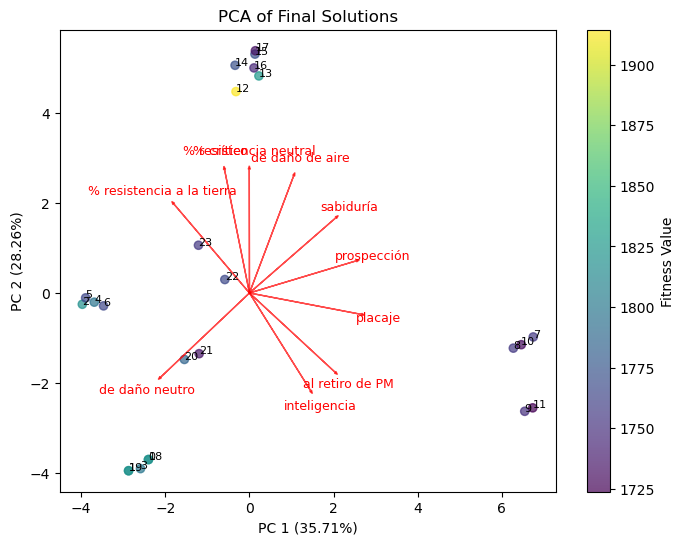

Gene contributions to each PC:


Text(0.5, 1.0, 'PC2 Contributions')

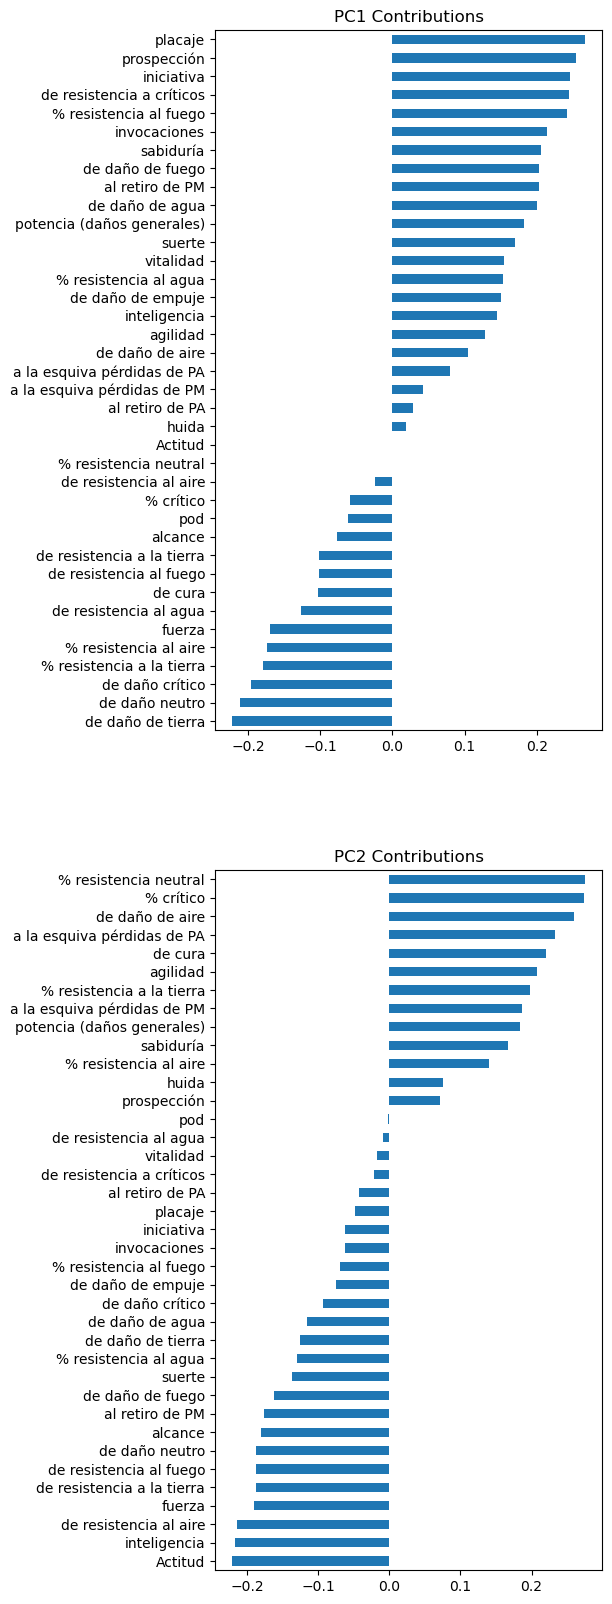

In [12]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Suppose 'solutions' is your (n_solutions, n_genes) array
# solutions = np.array([...])

# Normalize totals
df_totals_normalized = (df_totals - df_totals.mean()) / df_totals.std()
df_totals_normalized = df_totals_normalized.dropna(axis=1)

# Run PCA
n_components = 2
pca = PCA(n_components=n_components)
principal_components = pca.fit_transform(df_totals_normalized.values)

# Visualize
plt.figure(figsize=(8,6))
# Mask data points with fitness value
# plt.scatter(principal_components[:,0], principal_components[:,1], alpha=0.7)
plt.scatter(principal_components[:,0], principal_components[:,1], c=lst_fitness, cmap='viridis', alpha=0.7)
plt.colorbar(label='Fitness Value')
# Plot the index of each point
for i in range(len(principal_components)):
    plt.annotate(i, (principal_components[i, 0], principal_components[i, 1]), fontsize=8)

# Calculate variance explained by each PC
explained_variance = pca.explained_variance_ratio_
plt.xlabel(f'PC 1 ({explained_variance[0]:.2%})')
plt.ylabel(f'PC 2 ({explained_variance[1]:.2%})')
plt.title('PCA of Final Solutions')

# Add quivers
import numpy as np
# Loadings for PC1 and PC2 for each feature
loadings = pca.components_[:2, :]  # shape (2, n_features)
loading_magnitudes = np.linalg.norm(loadings, axis=0)  # shape (n_features,)

top_n = 10  # or 15, or whatever number you want
top_indices = np.argsort(loading_magnitudes)[-top_n:]  # indices of top N features

stat_names = df_totals_normalized.columns.tolist()  # Replace with your stat names if you have them
scaling = 10  # Adjust as needed for visibility

for i in top_indices:
    x = pca.components_[0, i]
    y = pca.components_[1, i]
    plt.arrow(0, 0, x*scaling, y*scaling, color='r', alpha=0.7, head_width=0.05)
    plt.text(x*scaling*1.15, y*scaling*1.15, stat_names[i], color='r', ha='center', va='center', fontsize=9)

plt.show()

# Inspect contributions
gene_names = df_totals_normalized.columns.tolist()
pc_df = pd.DataFrame(pca.components_, columns=gene_names, index=[f"PC{i+1}" for i in range(n_components)])
print("Gene contributions to each PC:")
# pc_df.T.sort_values(by='PC1', ascending=True)
fig,ax = plt.subplots(2,1,figsize=(5, 20))
pc_df.T.sort_values(by='PC1', ascending=True)["PC1"].plot.barh(ax=ax[0])
ax[0].set_title("PC1 Contributions")
pc_df.T.sort_values(by='PC2', ascending=True)["PC2"].plot.barh(ax=ax[1])
ax[1].set_title("PC2 Contributions")

In [ ]:
chr = Chromosome(candidates[4],opt)
chr.set_summary()["set"].value_counts()

set
Set de Corrupción             2
Set de Fuji Gélifux           1
Set de Ogivol Scarratero      1
Set de kukoloide              1
Set de cortesano tenebroso    1
Set de Mami Ayuto             1
Name: count, dtype: int64

In [ ]:
chr.totals_summary(effect_descriptions).sort_values("value", ascending=False)

,description,value
9,vitalidad,4070.0
45,fuerza,1266.0
24,iniciativa,1100.0
10,sabiduría,470.0
36,agilidad,350.0
22,suerte,330.0
13,inteligencia,280.0
98,Actitud,185.0
49,de daño neutro,118.0
48,de daño de tierra,118.0


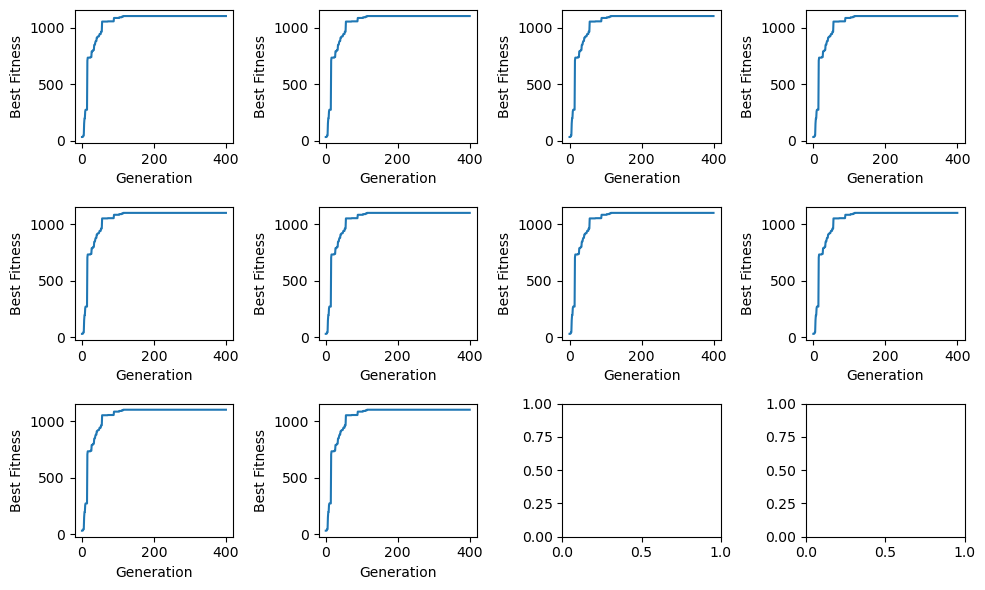

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
depth = int(np.ceil(len(solutions)/4))
fig,ax = plt.subplots(depth,4,figsize=(10,depth*2))
ax = ax.flatten()
for axi,solution in zip(ax,solutions):
    axi.plot(solutions[0].best_solutions_fitness)
    axi.set_xlabel('Generation')
    axi.set_ylabel('Best Fitness')

fig.tight_layout()

In [ ]:
assert False

AssertionError: 

In [ ]:
# Current
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
Items[Items["name"].str.contains("kuko")]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)